In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
np.random.seed(0)

orientations = np.linspace(0, 180, num=16, endpoint=False)
N = 40000
H, W = 16, 16
num_cycles = 3
period = H / num_cycles

#### Train Data

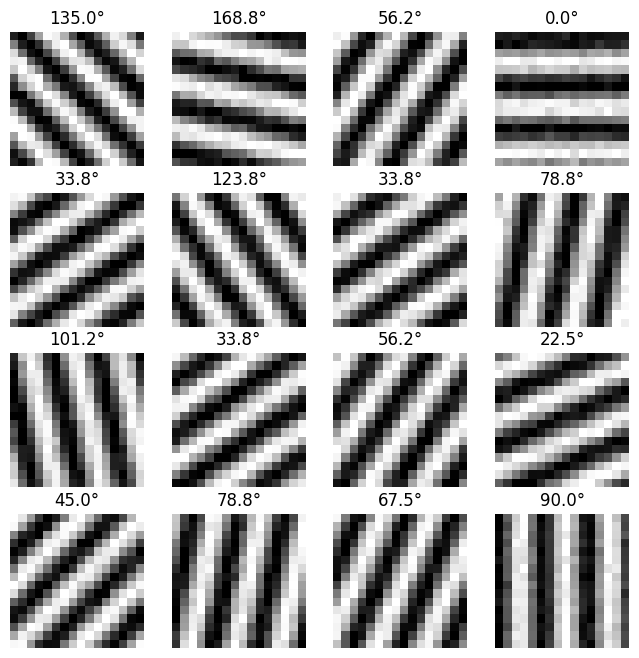

In [3]:
x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

cosA = np.cos(A)
sinA = np.sin(A)

idx_oris = np.random.choice(len(orientations), size=N, replace=True)
phases = np.random.rand(N) * 2 * np.pi
cphi = np.cos(phases)[:, None, None]
sphi = np.sin(phases)[:, None, None]

cosA_sel = cosA[idx_oris]
sinA_sel = sinA[idx_oris]

gratings = 0.5 * (1 + (cosA_sel * cphi - sinA_sel * sphi))

noise = np.random.normal(0, 0.05, size=(N, H, W))
train_imgs = np.clip(gratings + noise, 0, 1)

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(train_imgs[i * 4 + j], cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientations[idx_oris[i * 4 + j]]:.1f}°')

In [4]:
sio.savemat('train_gratings.mat', {'images': train_imgs, 'orientations': orientations[idx_oris]})

#### Test Data

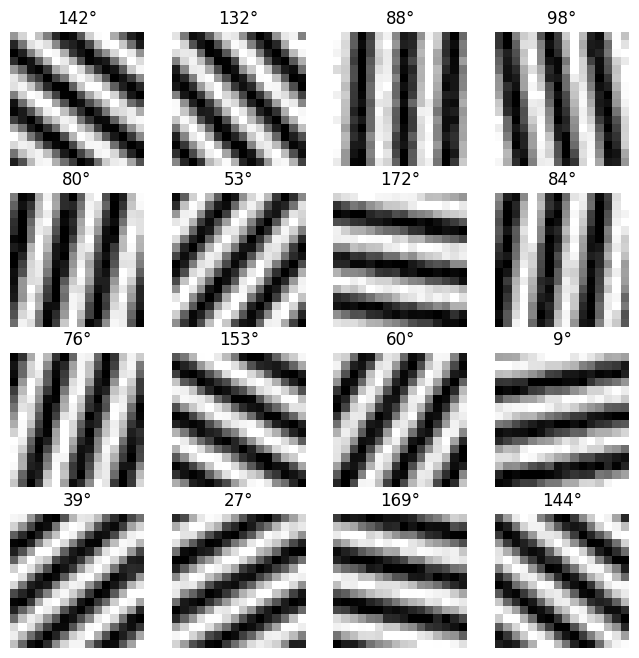

In [5]:
orientations = np.arange(0, 180)
trials = 30

x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

cosA = np.cos(A)
sinA = np.sin(A)

idx_oris = np.repeat(orientations, trials)
phases = np.random.rand(len(orientations), trials) * 2 * np.pi
cphi = np.cos(phases)[:, :, None, None]
sphi = np.sin(phases)[:, :, None, None]

cosA_exp = cosA[:, None, :, :]
sinA_exp = sinA[:, None, :, :]

gratings = 0.5 * (1 + (cosA_exp * cphi - sinA_exp * sphi))

noise = np.random.normal(0, 0.05, size=(len(orientations), trials, H, W))
test_imgs = np.clip(gratings + noise, 0, 1)

fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        orientation = np.random.randint(len(test_imgs))
        img = test_imgs[orientation, 0]
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientation}°')

In [6]:
sio.savemat('test_gratings.mat', {'images': test_imgs})

#### Psychometric Data

(6, 51, 2, 30, 16, 16)


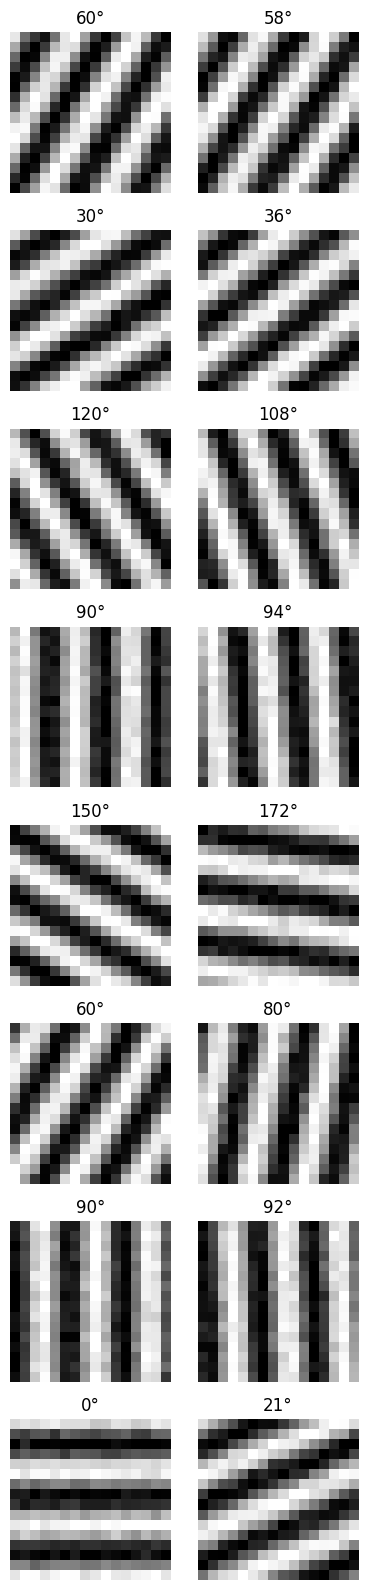

In [7]:
ref_angles = np.arange(0, 180, 30)
delta_range = np.arange(-25, 26)
n_psych_trials = 30

all_oris = ref_angles[:, None] + delta_range[None, :]
thetas = np.deg2rad(all_oris)

x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

cos_t = np.cos(thetas)[..., None, None]
sin_t = np.sin(thetas)[..., None, None]

A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

cosA = np.cos(A)
sinA = np.sin(A)

phases = np.random.rand(len(ref_angles), len(delta_range), n_psych_trials) * 2 * np.pi
cphi = np.cos(phases)[..., None, None]
sphi = np.sin(phases)[..., None, None]

cosA_exp = cosA[:, :, None, :, :]
sinA_exp = sinA[:, :, None, :, :]

test_gratings = 0.5 * (1 + (cosA_exp * cphi - sinA_exp * sphi))

ref_thetas = np.deg2rad(ref_angles)
cos_ref = np.cos(ref_thetas)[:, None, None]
sin_ref = np.sin(ref_thetas)[:, None, None]

A_ref = 2 * np.pi * (cos_ref * X + sin_ref * Y) / period
cosA_ref = np.cos(A_ref)
sinA_ref = np.sin(A_ref)

cosA_ref_exp = cosA_ref[:, None, None, :, :]
sinA_ref_exp = sinA_ref[:, None, None, :, :]

ref_gratings = 0.5 * (1 + (cosA_ref_exp * cphi - sinA_ref_exp * sphi))

pair_gratings = np.stack([ref_gratings, test_gratings], axis=2)
print(pair_gratings.shape)

noise = np.random.normal(0, 0.05, size=(len(ref_angles), len(delta_range), 2, n_psych_trials, H, W))
psych_imgs = np.clip(pair_gratings + noise, 0, 1)

fig, axs = plt.subplots(8, 2, figsize=(4, 16))
for i in range(8):
    ref_ind = np.random.randint(len(psych_imgs))
    ref_ori = ref_angles[ref_ind]
    delta_ind = np.random.randint(len(delta_range))
    test_ori = ref_ori + delta_range[delta_ind]
    ref_img = psych_imgs[ref_ind, delta_ind, 0, 0]
    test_img = psych_imgs[ref_ind, delta_ind, 1, 0]
    axs[i, 0].imshow(ref_img, cmap='gray')
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'{ref_ori}°')
    axs[i, 1].imshow(test_img, cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'{test_ori}°')
fig.tight_layout()
plt.show()

In [8]:
sio.savemat('psychometric_gratings.mat', {'images': psych_imgs})

In [9]:
psych_imgs.shape

(6, 51, 2, 30, 16, 16)

In [10]:
print(f'All combined images take up {(train_imgs.nbytes + test_imgs.nbytes + psych_imgs.nbytes) / (2 ** 20):.2f} MB of memory.')

All combined images take up 124.53 MB of memory.
